# Encontro 1 — Ler o painel: é ruído ou é problema?

**Cenário:** uma **fábrica de móveis planejados**. O sistema de chão de fábrica
registra *ocorrências* (paradas, refugo, retrabalho) por máquina, turno e produto.
Seu papel é o de **analista de problemas**: olhar o painel e separar o *incidente
isolado* do *problema de verdade*, usando quatro lentes:

1. **Tendência** — o volume está estável ou subindo de forma sustentada?
2. **Pareto (80/20)** — poucas máquinas concentram a maioria das ocorrências?
3. **Recorrência** — a mesma falha se repete? (volume baixo também pode ser problema)
4. **Severidade ≠ problema** — um evento gravíssimo que aconteceu uma vez é incidente, não problema.

> A teoria de ITIL (Incident vs Problem, Known Error, workaround) você já domina.
> Aqui o foco é a **leitura do dado** que sustenta a decisão.

## Da fábrica para a TI

Tudo que você treina aqui no chão de fábrica tem o equivalente direto em Problem
Management de TI — a régua de decisão é a mesma, muda só o vocabulário.

| Chão de fábrica | TI / ITIL 4 |
|---|---|
| Ocorrência (parada, refugo, retrabalho) | **Incidente** |
| Máquina que gera refugo recorrente | **Problema** |
| Reapertar / recalibrar todo turno para seguir produzindo | **Workaround** |
| Causa identificada + contorno documentado | **Known Error** (KEDB) |
| Manutenção preventiva / padrão de calibração | **Solução permanente** (corrige a causa-raiz) |
| Refugo e retrabalho (R$) | **Impacto de negócio** |
| Máquina / linha / turno | Serviço / componente / janela |

**Dataset:** log sintético de **90 dias** de uma fábrica (operação 24x7, três turnos).

In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Renderiza gráficos como imagem estática (visível no GitHub e em qualquer viewer).
# Para INTERATIVO na sessão ao vivo, troque a linha abaixo por: pio.renderers.default = "notebook"
pio.renderers.default = "png"
pio.templates.default = "plotly_white"

df = pd.read_csv("../data/ocorrencias.csv", parse_dates=["aberto_em", "resolvido_em"])
print(f"{len(df)} ocorrências | {df['aberto_em'].min().date()} a {df['aberto_em'].max().date()}")
df.head()

343 ocorrências | 2025-03-01 a 2025-05-29


,ocorrencia_id,aberto_em,resolvido_em,maquina,produto,tipo_defeito,gravidade,turno,descricao,tempo_resolucao_h
0,OC00001,2025-03-01 20:01:58,2025-03-02 02:24:58.548135866,Embaladora-01,Cômoda,falha-embalagem,Alto,Noite,Falha no filme de embalagem,6.38
1,OC00002,2025-03-03 10:48:39,2025-03-07 04:38:26.222001988,Serra-02,Cômoda,corte-fora-medida,Baixo,Tarde,Corte fora de medida na Serra-02,89.83
2,OC00003,2025-03-03 14:08:38,2025-03-05 18:30:02.177004614,Embaladora-01,Mesa de jantar,falha-embalagem,Baixo,Tarde,Falha no filme de embalagem,52.36
3,OC00004,2025-03-03 20:48:43,2025-03-04 01:25:19.337923907,Furadeira-01,Criado-mudo,furo-descentralizado,Médio,Tarde,Furo descentralizado no painel,4.61
4,OC00005,2025-03-03 22:39:04,2025-03-05 20:37:15.887616233,Serra-01,Estante,corte-fora-esquadro,Alto,Tarde,Corte fora de esquadro no painel,45.97


## 0. O painel cru não é insight

Uma tabela de 343 linhas não responde "existe um problema?". Ela só lista eventos.
O trabalho do analista é **transformar esse log em sinal**. Vamos por partes.

## 1. KPIs — o que fica no topo de um painel de operações

Antes de caçar problemas, leia a saúde geral: volume, severidade e tempo de resolução
(MTTR). São os números que a liderança pergunta primeiro.

In [2]:
kpis = {
    "Ocorrências (total)":      len(df),
    "Críticas":                 int((df.gravidade == "Crítico").sum()),
    "MTTR mediano (h)":         round(df.tempo_resolucao_h.median(), 1),
    "MTTR crítico mediano (h)": round(df.loc[df.gravidade == "Crítico", "tempo_resolucao_h"].median(), 1),
    "Máquinas distintas":       df.maquina.nunique(),
}
pd.DataFrame(kpis, index=["valor"]).T

,valor
Ocorrências (total),343.0
Críticas,5.0
MTTR mediano (h),24.0
MTTR crítico mediano (h),5.0
Máquinas distintas,10.0


## 2. Tendência — incidente isolado vs problema sustentado

Um pico de um dia é, na maioria das vezes, um **incidente**. O que acende a luz de
*problema* é uma tendência que **sobe e se mantém**. Olhamos o volume semanal total
e, em seguida, separado pelas máquinas que mais aparecem.

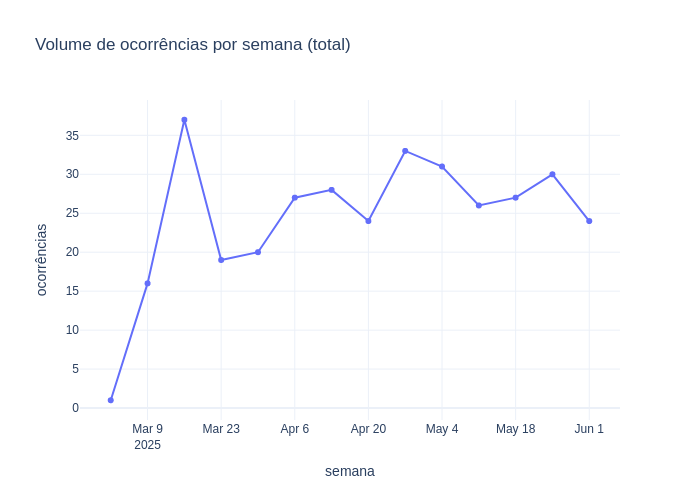

In [3]:
semanal = df.set_index("aberto_em").resample("W").size().reset_index(name="ocorrencias")
fig = px.line(semanal, x="aberto_em", y="ocorrencias", markers=True,
              title="Volume de ocorrências por semana (total)")
fig.update_layout(xaxis_title="semana", yaxis_title="ocorrências")
fig.show()

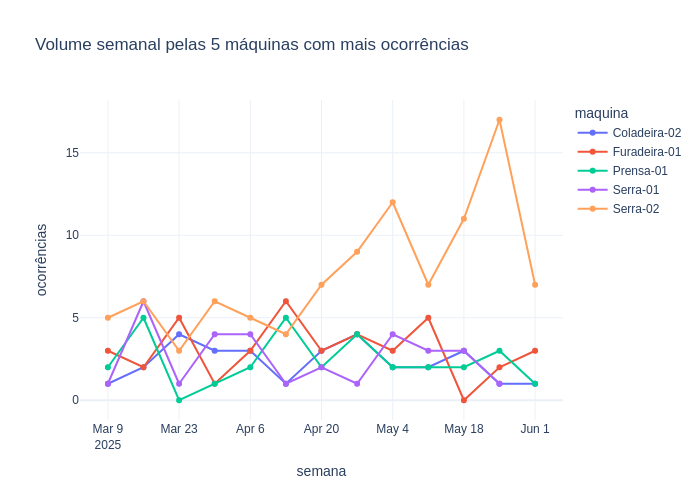

In [4]:
top5 = df.maquina.value_counts().head(5).index
wk_maq = (df[df.maquina.isin(top5)]
          .set_index("aberto_em").groupby("maquina").resample("W").size()
          .reset_index(name="ocorrencias"))
fig = px.line(wk_maq, x="aberto_em", y="ocorrencias", color="maquina", markers=True,
              title="Volume semanal pelas 5 máquinas com mais ocorrências")
fig.update_layout(xaxis_title="semana", yaxis_title="ocorrências")
fig.show()

**Leia o gráfico:** uma máquina desenha uma rampa clara de subida ao longo das
semanas, enquanto as outras oscilam em torno de um patamar. *Rampa sustentada = candidato a problema.*

## 3. Pareto — a regra 80/20

Poucas máquinas costumam concentrar a maior parte das ocorrências. Ordenamos por
volume e somamos o percentual acumulado: onde a curva acumulada cruza ~80% você
encontra as "poucas vitais" que merecem virar registro de problema.

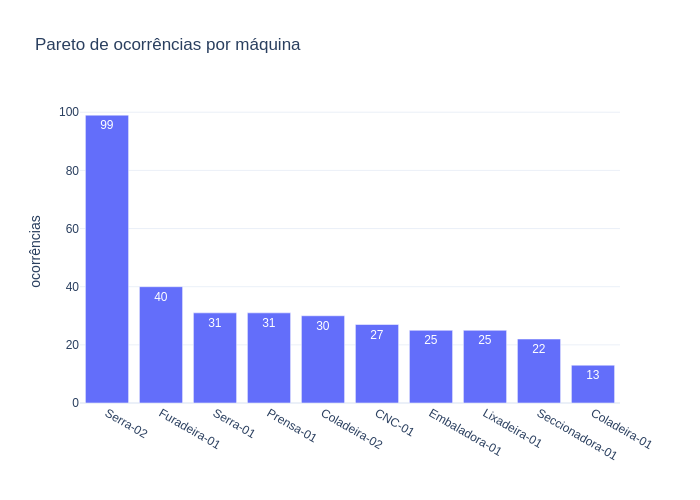

,maquina,ocorrencias,acumulado_%
0,Serra-02,99,28.9
1,Furadeira-01,40,40.5
2,Serra-01,31,49.6
3,Prensa-01,31,58.6
4,Coladeira-02,30,67.3
5,CNC-01,27,75.2
6,Embaladora-01,25,82.5
7,Lixadeira-01,25,89.8
8,Seccionadora-01,22,96.2
9,Coladeira-01,13,100.0


In [5]:
por_maq = df.maquina.value_counts().reset_index()
por_maq.columns = ["maquina", "ocorrencias"]
por_maq["acumulado_%"] = (por_maq.ocorrencias.cumsum() / por_maq.ocorrencias.sum() * 100).round(1)

fig = px.bar(por_maq, x="maquina", y="ocorrencias", text="ocorrencias",
             title="Pareto de ocorrências por máquina")
fig.update_layout(xaxis_title="", yaxis_title="ocorrências")
fig.show()
por_maq

**Leia o gráfico:** a primeira máquina sozinha responde por uma fatia
desproporcional do total. É a suspeita nº 1 — note o tamanho do degrau entre ela e a segunda.

## 4. Recorrência — volume baixo também pode ser problema

Pareto premia volume. Mas uma falha que **se repete com a mesma assinatura** é problema
mesmo sem aparecer no topo. Agrupamos por `máquina + descrição` para achar reincidências.

In [6]:
recorr = (df.groupby(["maquina", "descricao"]).size()
          .reset_index(name="ocorrencias")
          .sort_values("ocorrencias", ascending=False))
recorr.head(10)

,maquina,descricao,ocorrencias
18,Serra-02,Corte fora de medida na Serra-02,99
7,Furadeira-01,Furo descentralizado no painel,25
3,Coladeira-02,Bolhas na fita de borda,21
16,Serra-01,Corte fora de esquadro no painel,17
13,Prensa-01,Pressão fora do padrão na prensagem,15
0,CNC-01,Desgaste de ferramenta no usinado,15
11,Prensa-01,Delaminação do painel prensado,15
10,Lixadeira-01,Lixa desgastada antes do previsto,15
5,Embaladora-01,Etiqueta ilegível na expedição,15
8,Furadeira-01,Quebra de broca durante a furação,15


**Leia a tabela:** além da campeã de volume, procure assinaturas que se repetem
**dezenas de vezes idênticas** ou que reincidem em cadência regular mesmo com contagem
modesta. Recorrência regular = problema, ainda que fora do topo do Pareto.

## 5. Baseline e desvio — a suspeita está fugindo do "normal"?

Confirmar tendência: comparamos o volume semanal da suspeita contra a **média das
primeiras semanas** (o baseline). Se as semanas recentes estão consistentemente acima,
não é variação aleatória — é degradação.

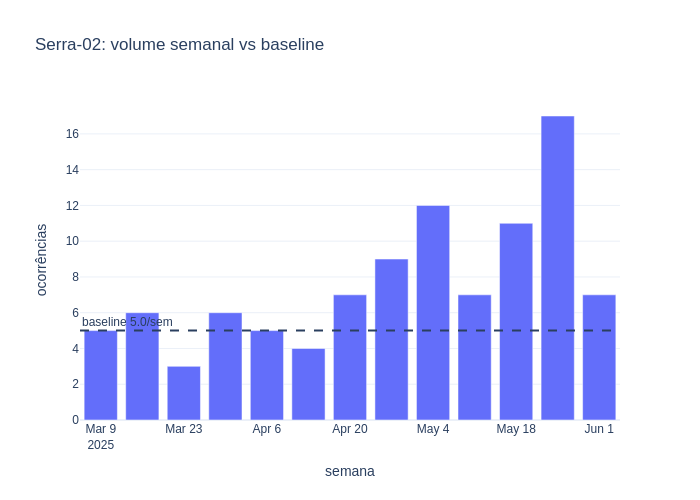

Baseline (4 primeiras semanas): 5.0/sem | Últimas 4 semanas: 10.5/sem


In [7]:
suspeita = df.maquina.value_counts().index[0]   # a líder do Pareto
s = df[df.maquina == suspeita].set_index("aberto_em").resample("W").size()
baseline = s.iloc[:4].mean()   # média das 4 primeiras semanas

ax = s.reset_index(name="ocorrencias")
fig = px.bar(ax, x="aberto_em", y="ocorrencias",
             title=f"{suspeita}: volume semanal vs baseline")
fig.add_hline(y=baseline, line_dash="dash",
              annotation_text=f"baseline {baseline:.1f}/sem", annotation_position="top left")
fig.update_layout(xaxis_title="semana", yaxis_title="ocorrências")
fig.show()
print(f"Baseline (4 primeiras semanas): {baseline:.1f}/sem | Últimas 4 semanas: {s.iloc[-4:].mean():.1f}/sem")

## 6. O distrator — severidade alta ≠ problema

Nem todo evento crítico vira problema. Uma ocorrência gravíssima que **aconteceu uma
única vez e nunca mais se repetiu** é um incidente bem gerido — não um problema. Sem
recorrência e sem tendência, não há causa sistêmica para perseguir.

In [8]:
crit = df[df.gravidade == "Crítico"][["ocorrencia_id", "aberto_em", "maquina", "descricao"]]
print(f"{len(crit)} ocorrências críticas no período")
# Alguma crítica se repete (mesma assinatura)? Conte ocorrências por descrição:
crit.assign(ocorrencias=crit.groupby("descricao")["descricao"].transform("size")) \
    .sort_values("ocorrencias", ascending=False).head(10)

5 ocorrências críticas no período


,ocorrencia_id,aberto_em,maquina,descricao,ocorrencias
61,OC00062,2025-03-19 23:30:05,Coladeira-02,Cola fora da temperatura de trabalho,1
133,OC00134,2025-04-10 08:56:03,Prensa-01,Incêndio no painel elétrico (evento isolado),1
168,OC00169,2025-04-19 23:50:02,Furadeira-01,Furo descentralizado no painel,1
190,OC00191,2025-04-25 00:55:30,Embaladora-01,Etiqueta ilegível na expedição,1
225,OC00226,2025-05-03 03:58:18,Prensa-01,Delaminação do painel prensado,1


**Leia a tabela:** o "Incêndio no painel elétrico" é Crítico e assusta, mas tem
**1 ocorrência**. É incidente, não problema. Compare com a suspeita do Pareto, que é
Alto/Médio mas se repete às dezenas — *essa* é o problema.

## 7. Ferramenta de investigação

Para investigar qualquer máquina com uma linha só (volume, tendência, assinaturas):

Furadeira-01: 40 ocorrências

Assinaturas mais comuns:
descricao
Furo descentralizado no painel       25
Quebra de broca durante a furação    15

Distribuição por turno:
turno
Noite    14
Tarde    13
Manhã    13


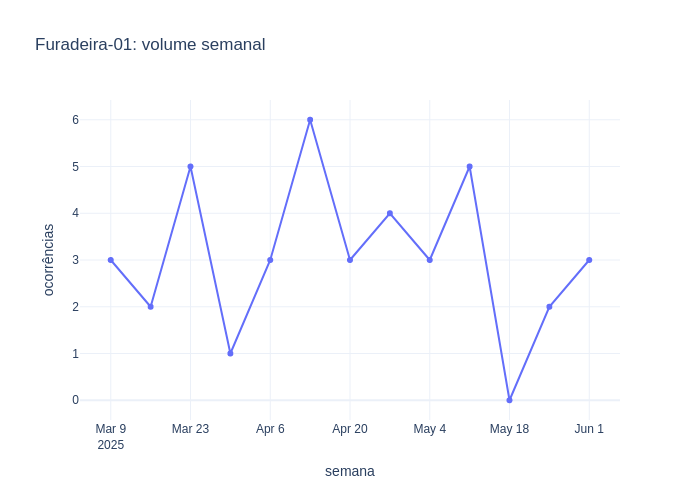

In [9]:
def investigar(maquina: str):
    sub = df[df.maquina == maquina]
    print(f"{maquina}: {len(sub)} ocorrências")
    print("\nAssinaturas mais comuns:")
    print(sub.descricao.value_counts().head(3).to_string())
    print("\nDistribuição por turno:")
    print(sub.turno.value_counts().to_string())
    wk = sub.set_index("aberto_em").resample("W").size().reset_index(name="ocorrencias")
    fig = px.line(wk, x="aberto_em", y="ocorrencias", markers=True,
                  title=f"{maquina}: volume semanal")
    fig.update_layout(xaxis_title="semana", yaxis_title="ocorrências")
    fig.show()

investigar("Furadeira-01")

## Exercício (sem resposta pronta)

Usando as quatro lentes (tendência, Pareto, recorrência, severidade) e a função
`investigar()`, responda **na célula abaixo**:

1. Quais máquinas são **candidatas a problema**? Justifique cada uma com a evidência
   (é tendência? Pareto? recorrência?).
2. Qual evento **parece** problema mas **não é**? Por quê?
3. Para a sua candidata nº 1, qual seria a próxima ação no fluxo de Problem Management?

> Investigue à vontade: `investigar("Serra-02")`, `investigar("Coladeira-01")`, etc.
> A correção comentada está no **guia do instrutor**, não aqui.

In [10]:
# Sua análise aqui. Ex.:
# investigar("Serra-02")
# investigar("Coladeira-01")
